In [9]:
# Cell 1: Import libraries and connect to SQL Server
import pyodbc
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Auto-pick best driver
drivers = pyodbc.drivers()
if "ODBC Driver 18 for SQL Server" in drivers:
    driver = "ODBC Driver 18 for SQL Server"
elif "ODBC Driver 17 for SQL Server" in drivers:
    driver = "ODBC Driver 17 for SQL Server"
else:
    driver = "SQL Server"

conn = pyodbc.connect(
    f"DRIVER={{{driver}}};"
    "SERVER=localhost\\SQLEXPRESS;"
    "DATABASE=ShopEasy;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

print(f"Connected using: {driver}")
print("Loading reviews from SQL Server...")

# Load the cleaned reviews table into a pandas DataFrame
# A DataFrame is like a Python version of a spreadsheet
df = pd.read_sql("SELECT * FROM customer_reviews_cleaned", conn)

print(f"Loaded {len(df)} reviews")
df.head()

Connected using: ODBC Driver 18 for SQL Server
Loading reviews from SQL Server...
Loaded 1363 reviews


C:\Users\Sadiya\AppData\Local\Temp\ipykernel_7780\3463676360.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM customer_reviews_cleaned", conn)


,ReviewID,CustomerID,ProductID,ReviewDate,Rating,ReviewText
0,1,911,9,2023-07-04,5,"Perfect for my needs, very happy with this pur..."
1,2,718,10,2024-04-09,5,"Absolutely love this product, exceeded my expe..."
2,3,829,14,2023-05-13,3,Works fine but instructions were confusing.
3,4,182,3,2023-12-02,2,Delivery was slow and product did not match th...
4,5,122,7,2024-04-29,3,Good product overall but the price is a bit high.


In [10]:
# Cell 2: Run VADER sentiment scoring on every review
# VADER gives each review a 'compound' score from -1.0 to +1.0
# -1.0 = most negative possible
#  0.0 = neutral
# +1.0 = most positive possible

analyzer = SentimentIntensityAnalyzer()

def get_vader_score(text):
    scores = analyzer.polarity_scores(str(text))
    return scores['compound']  # we only need the overall compound score

# Apply the function to every row in the ReviewText column
df['vader_score'] = df['ReviewText'].apply(get_vader_score)

print("VADER scoring complete!")
print(f"\nScore range: {df['vader_score'].min():.2f} to {df['vader_score'].max():.2f}")
print(f"Average score: {df['vader_score'].mean():.2f}")
df[['ReviewText', 'Rating', 'vader_score']].head(10)

VADER scoring complete!

Score range: -0.64 to 0.83
Average score: 0.50


,ReviewText,Rating,vader_score
0,"Perfect for my needs, very happy with this pur...",5,0.8268
1,"Absolutely love this product, exceeded my expe...",5,0.6989
2,Works fine but instructions were confusing.,3,-0.2382
3,Delivery was slow and product did not match th...,2,0.0000
4,Good product overall but the price is a bit high.,3,0.2382
5,The quality does not meet expectations I had.,1,0.0000
6,"Average product, nothing special about it.",1,-0.3089
7,Works fine but instructions were confusing.,3,-0.2382
8,"Great quality and fast delivery, highly recomm...",5,0.7841
9,Quality is acceptable but expected better for ...,3,0.6705


In [11]:
# Cell 3: Hybrid sentiment classification
# Pure VADER alone has gaps — it sometimes scores clearly positive text as neutral
# Solution: combine VADER score WITH the star rating for better accuracy
# This gives us 5 categories that capture nuance

def classify_sentiment(row):
    score = row['vader_score']
    rating = row['Rating']
    
    if score >= 0.05 and rating >= 4:
        return 'Positive'
    elif score <= -0.05 and rating <= 2:
        return 'Negative'
    elif score <= -0.05 and rating >= 3:
        return 'Mixed Negative'   # text sounds bad but rating is okay
    elif score >= 0.05 and rating <= 3:
        return 'Mixed Positive'   # text sounds good but rating is low
    else:
        return 'Neutral'

df['sentiment_category'] = df.apply(classify_sentiment, axis=1)

# Show the distribution
sentiment_counts = df['sentiment_category'].value_counts()
print("Sentiment distribution:")
print(sentiment_counts)
print(f"\nTotal reviews: {len(df)}")

Sentiment distribution:
sentiment_category
Positive          974
Neutral           132
Negative          113
Mixed Positive    106
Mixed Negative     38
Name: count, dtype: int64

Total reviews: 1363


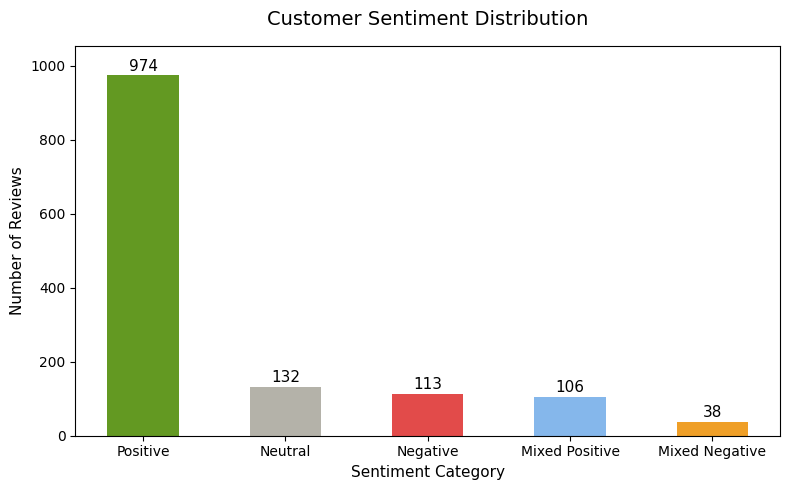

Chart saved as sentiment_distribution.png


In [12]:
# Cell 4: Visualise the sentiment breakdown as a bar chart

colors = {
    'Positive':       '#639922',
    'Negative':       '#E24B4A', 
    'Mixed Negative': '#EF9F27',
    'Mixed Positive': '#85B7EB',
    'Neutral':        '#B4B2A9'
}

fig, ax = plt.subplots(figsize=(8, 5))

categories = sentiment_counts.index.tolist()
values     = sentiment_counts.values.tolist()
bar_colors = [colors.get(c, '#888780') for c in categories]

bars = ax.bar(categories, values, color=bar_colors, width=0.5)

# Add count labels on top of each bar
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=11)

ax.set_title('Customer Sentiment Distribution', fontsize=14, pad=15)
ax.set_xlabel('Sentiment Category', fontsize=11)
ax.set_ylabel('Number of Reviews', fontsize=11)
ax.set_ylim(0, max(values) + 80)
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as sentiment_distribution.png")

In [13]:
# Cell 5: Find the top complaint themes in negative reviews
# We filter only Negative + Mixed Negative reviews
# Then count the most frequent complaint words
# This tells us WHY customers are unhappy

negative_df = df[df['sentiment_category'].isin(['Negative', 'Mixed Negative'])].copy()
print(f"Total negative/mixed-negative reviews: {len(negative_df)}")

# Define keyword categories — these were identified by reading the reviews
# Each theme groups related words together
themes = {
    'Unmet Expectations': ['expectations', 'expected', 'disappoint', 'meet', 'average'],
    'Product Cost':       ['price', 'expensive', 'overpriced', 'worth', 'cost'],
    'Product Performance':['performance', 'quality', 'broke', 'broke', 'poor', 'bad'],
    'Delivery':           ['delivery', 'slow', 'late', 'shipping', 'arrived']
}

def find_theme(text):
    text_lower = str(text).lower()
    for theme, keywords in themes.items():
        if any(kw in text_lower for kw in keywords):
            return theme
    return 'Other'

negative_df['complaint_theme'] = negative_df['ReviewText'].apply(find_theme)

theme_counts = negative_df['complaint_theme'].value_counts()
print("\nComplaint themes in negative reviews:")
print(theme_counts)

Total negative/mixed-negative reviews: 151

Complaint themes in negative reviews:
complaint_theme
Unmet Expectations     63
Product Performance    50
Other                  38
Name: count, dtype: int64


In [14]:
# Cell 6: Export results to CSV files
# These CSVs will be used by Power BI for the dashboard
# They'll also go into your GitHub repository

# CSV 1: All reviews with sentiment scores and categories
output_cols = ['ReviewID', 'CustomerID', 'ProductID', 'ReviewDate', 
               'Rating', 'ReviewText', 'vader_score', 'sentiment_category']
df[output_cols].to_csv('customer_reviews_sentiment.csv', index=False)
print("Saved: customer_reviews_sentiment.csv")

# CSV 2: Negative reviews with complaint themes
neg_cols = ['ReviewID', 'CustomerID', 'ProductID', 'ReviewDate',
            'Rating', 'ReviewText', 'vader_score', 'sentiment_category', 'complaint_theme']
negative_df[neg_cols].to_csv('negative_reviews_issues.csv', index=False)
print("Saved: negative_reviews_issues.csv")

print(f"\nSummary:")
print(f"  Total reviews analysed:    {len(df)}")
print(f"  Positive:                  {len(df[df['sentiment_category']=='Positive'])}")
print(f"  Negative:                  {len(df[df['sentiment_category']=='Negative'])}")
print(f"  Mixed Negative:            {len(df[df['sentiment_category']=='Mixed Negative'])}")
print(f"  Mixed Positive:            {len(df[df['sentiment_category']=='Mixed Positive'])}")
print(f"  Neutral:                   {len(df[df['sentiment_category']=='Neutral'])}")
print(f"\nNegative reviews by theme:")
print(theme_counts)
print("\nSentiment analysis complete!")

Saved: customer_reviews_sentiment.csv
Saved: negative_reviews_issues.csv

Summary:
  Total reviews analysed:    1363
  Positive:                  974
  Negative:                  113
  Mixed Negative:            38
  Mixed Positive:            106
  Neutral:                   132

Negative reviews by theme:
complaint_theme
Unmet Expectations     63
Product Performance    50
Other                  38
Name: count, dtype: int64

Sentiment analysis complete!
